# Medi-Cal Cost Prediction - Exploratory Data Analysis

## Datasets Analyzed:
1. **CPT/HCPCS Codes** - NLP training data
2. **Medi-Cal Rates Data** - Fee schedules for cost lookup
3. **Medi-Cal Provider Manuals** - Coverage rules for RAG system

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
warnings.filterwarnings('ignore')

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 10


---
## Part 1: Load Cleaned Data

In [17]:
df_rates = pd.read_csv('rates_data_cleaned.csv')
print("✓ Loaded rates data")
print(f"Shape: {df_rates.shape}")
print(f"\nColumns: {df_rates.columns.tolist()}")
df_rates.head()

✓ Loaded rates data
Shape: (19401, 21)

Columns: ['Proc Type', 'Proc Code', 'Procedure Description', 'Unit Value', 'Basic Rate', 'Child Rate', 'ER Rate', 'Conv Ind', 'ER Ind', 'Cutback Ind', 'Prof %', 'Rental Rate', 'Non-Physn Med Prac Ind', 'Proc Code_numeric', 'Unit Value_numeric', 'Basic Rate_numeric', 'Conv Ind_numeric', 'ER Ind_numeric', 'Cutback Ind_numeric', 'Prof %_numeric', 'Rental Rate_numeric']


,Proc Type,Proc Code,Procedure Description,Unit Value,Basic Rate,Child Rate,ER Rate,Conv Ind,ER Ind,Cutback Ind,...,Rental Rate,Non-Physn Med Prac Ind,Proc Code_numeric,Unit Value_numeric,Basic Rate_numeric,Conv Ind_numeric,ER Ind_numeric,Cutback Ind_numeric,Prof %_numeric,Rental Rate_numeric
0,M,0001U,RBC DNA HEA 35 AG 11 BLD GRP,576.00,$576.00,---,--,9,0,0,...,$0.00,N,NaN,576.00,576.00,9,0,0,0.0,0.0
1,M,0003U,ONC OVAR 5 PRTN SER ALG SCOR,760.00,$760.00,---,--,9,0,0,...,$0.00,N,NaN,760.00,760.00,9,0,0,0.0,0.0
2,M,0007U,RX TEST PRSMV UR W/DEF CONF,91.54,$91.54,---,--,9,0,0,...,$0.00,N,NaN,91.54,91.54,9,0,0,0.0,0.0
3,J,00100,ANES PX SALIVARY GLAND W/BX,4.52,$63.33,---,--,2,0,0,...,$0.00,Y,100.0,4.52,63.33,2,0,0,0.0,0.0
4,J,00102,ANES PX PLSTC RPR CLEFT LIP,5.42,$75.93,---,--,2,0,0,...,$0.00,Y,102.0,5.42,75.93,2,0,0,0.0,0.0


In [18]:
df_cpt = pd.read_csv('cpt_with_rates.csv')
print("✓ Loaded CPT/HCPCS dataset with rates")
print(f"Shape: {df_cpt.shape}")
print(f"\nColumns: {df_cpt.columns.tolist()}")
df_cpt.head()

✓ Loaded CPT/HCPCS dataset with rates
Shape: (22181, 13)

Columns: ['index', 'code', 'title', 'category', 'description', 'type', 'code_normalized', 'in_medi_cal', 'Proc Type', 'Basic Rate', 'Unit Value', 'Non-Physn Med Prac Ind', 'has_rate']


,index,code,title,category,description,type,code_normalized,in_medi_cal,Proc Type,Basic Rate,Unit Value,Non-Physn Med Prac Ind,has_rate
0,0,100,"""Anesthesia for Procedures on the Head.Anesthe...",Anesthesiology,"""The provider performs anesthesia services for...",CPT,100,False,NaN,NaN,NaN,NaN,False
1,1,102,"""Anesthesia for Procedures on the Head.Anesthe...",Anesthesiology,"""The provider performs anesthesia services for...",CPT,102,False,NaN,NaN,NaN,NaN,False
2,2,103,"""Anesthesia for Procedures on the Head.Anesthe...",Anesthesiology,"""The provider performs anesthesia services for...",CPT,103,False,NaN,NaN,NaN,NaN,False
3,3,104,"""Anesthesia for Procedures on the Head.Anesthe...",Anesthesiology,"""The provider performs anesthesia services for...",CPT,104,False,NaN,NaN,NaN,NaN,False
4,4,120,"""Anesthesia for Procedures on the Head.Anesthe...",Anesthesiology,"""The provider performs anesthesia services for...",CPT,120,False,NaN,NaN,NaN,NaN,False


In [4]:
# Ensure numeric columns exist
if 'Basic Rate_numeric' not in df_rates.columns:
    df_rates['Basic Rate_numeric'] = pd.to_numeric(
        df_rates['Basic Rate'].astype(str).str.replace('$', '').str.replace(',', ''), 
        errors='coerce'
    )

print("Basic Rate Statistics:")
df_rates['Basic Rate_numeric'].describe()

Basic Rate Statistics:


count    19401.000000
mean       367.326330
std       2255.383897
min          0.000000
25%         22.230000
50%        109.600000
75%        331.720000
max      98621.030000
Name: Basic Rate_numeric, dtype: float64

Procedure Type Distribution:
Proc Type
K    5778
O    4048
1    2549
M    1631
N    1073
P    1066
I     947
L     850
X     686
J     276
Name: count, dtype: int64


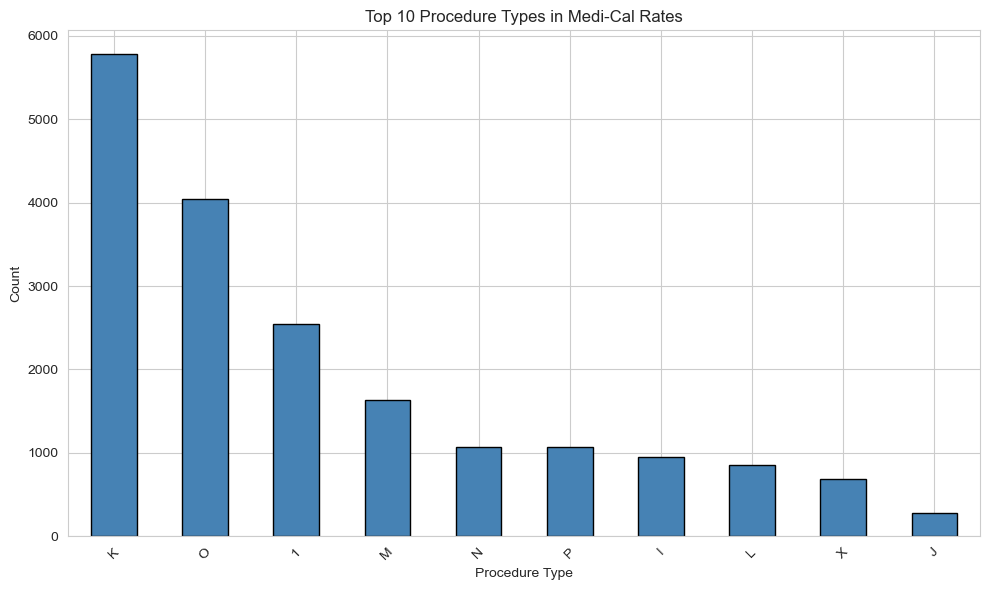

In [6]:
# Analyze procedure types
print("Procedure Type Distribution:")
proc_type_counts = df_rates['Proc Type'].value_counts()
print(proc_type_counts.head(10))

# Visualize
plt.figure(figsize=(10, 6))
proc_type_counts.head(10).plot(kind='bar', color='steelblue', edgecolor='black')
plt.xlabel('Procedure Type')
plt.ylabel('Count')
plt.title('Top 10 Procedure Types in Medi-Cal Rates')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('proc_type_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

In [15]:
# Data quality checks
print("Data Quality Summary:")
print(f"Total records: {len(df_rates):,}")
print(f"Unique codes: {df_rates['Proc Code'].nunique():,}")
print(f"Duplicate codes: {df_rates['Proc Code'].duplicated().sum():,}")


Data Quality Summary:
Total records: 19,401
Unique codes: 13,054
Duplicate codes: 6,347


---
Cross-Reference Analysis

In [ ]:

if 'code_normalized' not in df_cpt.columns and 'code' in df_cpt.columns:
    df_cpt['code_normalized'] = df_cpt['code'].astype(str).str.strip().str.upper()

if 'code_normalized' not in df_rates.columns:
    df_rates['code_normalized'] = df_rates['Proc Code'].astype(str).str.strip().str.upper()

cpt_codes = set(df_cpt['code_normalized'])
rate_codes = set(df_rates['code_normalized'])

codes_in_both = cpt_codes.intersection(rate_codes)
codes_only_cpt = cpt_codes - rate_codes
codes_only_rates = rate_codes - cpt_codes

print("Cross-Reference Analysis:")
print(f"Codes in CPT/HCPCS dataset: {len(cpt_codes):,}")
print(f"Codes in Medi-Cal rates: {len(rate_codes):,}")
print(f"Codes in BOTH: {len(codes_in_both):,} ({len(codes_in_both)/len(cpt_codes)*100:.1f}% of CPT)")
print(f"Codes ONLY in CPT/HCPCS: {len(codes_only_cpt):,}")
print(f"Codes ONLY in Rates: {len(codes_only_rates):,}")

Cross-Reference Analysis:
Codes in CPT/HCPCS dataset: 16,056
Codes in Medi-Cal rates: 13,054
Codes in BOTH: 11,365 (70.8% of CPT)
Codes ONLY in CPT/HCPCS: 4,691
Codes ONLY in Rates: 1,689


Coverage by Code Type:
      Covered  Total  Coverage %
type                            
CPT     14129  15110   93.507611
HCPS     3361   7071   47.532174


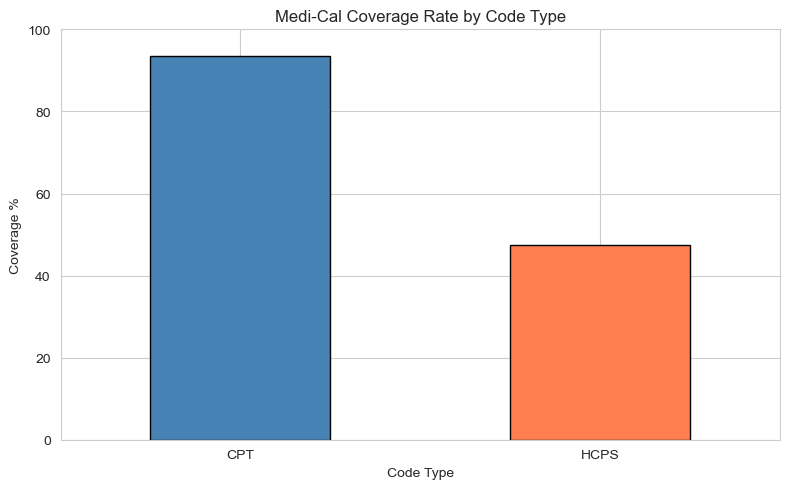

In [11]:
# Coverage by code type
if 'type' in df_cpt.columns:
    df_cpt['in_medi_cal'] = df_cpt['code_normalized'].isin(rate_codes)
    
    coverage_by_type = df_cpt.groupby('type')['in_medi_cal'].agg(['sum', 'count', 'mean'])
    coverage_by_type.columns = ['Covered', 'Total', 'Coverage %']
    coverage_by_type['Coverage %'] = coverage_by_type['Coverage %'] * 100
    
    print("Coverage by Code Type:")
    print(coverage_by_type)
    
    # Visualize
    coverage_by_type['Coverage %'].plot(kind='bar', color=['steelblue', 'coral'], edgecolor='black', figsize=(8, 5))
    plt.xlabel('Code Type')
    plt.ylabel('Coverage %')
    plt.title('Medi-Cal Coverage Rate by Code Type')
    plt.xticks(rotation=0)
    plt.ylim(0, 100)
    plt.tight_layout()
    plt.savefig('coverage_by_type.png', dpi=150, bbox_inches='tight')
    plt.show()

In [2]:
# The above was calulated by seeing if each code from Hugging face exists in Medi-cal rates. 
# Then groub by type 
# Calculate was (Covered Codes/Total Codes) * 100   

Coverage by Category (Top 15):
                                                    Covered  Total  Coverage %
category                                                                      
Surgery                                               10514  10716   98.114968
Pathology                                              2376   2779   85.498381
Medical Equipment and Supplies                          672   2063   32.573921
Transportation Services. medical equipment and ...      407   1252   32.507987
Injectable Drugs and infusion services                  674    989   68.149646
Orthotics and Prosthetics                               605    957   63.218391
Radiology                                               659    698   94.412607
Mental Health and Substance Abuse                       177    681   25.991189
Laboratory and Pathology Services                       482    648   74.382716
Other Services                                          285    362   78.729282
Evaluation and Manage

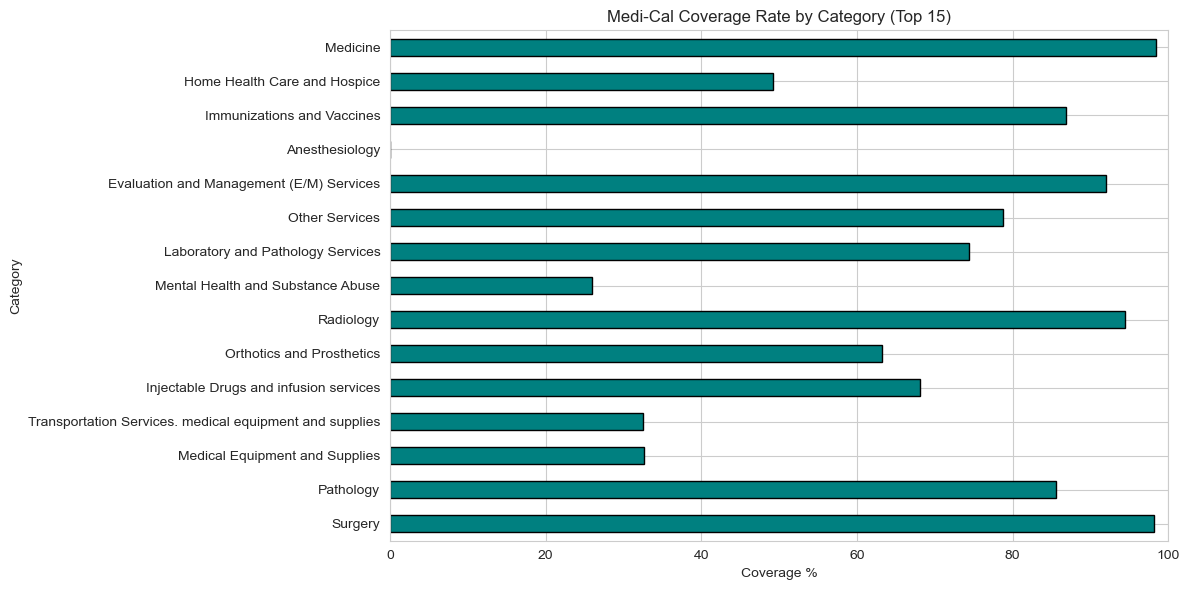

In [12]:
# Coverage by category (top 15)
if 'category' in df_cpt.columns and 'in_medi_cal' in df_cpt.columns:
    coverage_by_cat = df_cpt.groupby('category')['in_medi_cal'].agg(['sum', 'count', 'mean'])
    coverage_by_cat.columns = ['Covered', 'Total', 'Coverage %']
    coverage_by_cat['Coverage %'] = coverage_by_cat['Coverage %'] * 100
    coverage_by_cat = coverage_by_cat.sort_values('Total', ascending=False).head(15)
    
    print("Coverage by Category (Top 15):")
    print(coverage_by_cat)
    
    # Visualize
    fig, ax = plt.subplots(figsize=(12, 6))
    coverage_by_cat['Coverage %'].plot(kind='barh', color='teal', edgecolor='black', ax=ax)
    ax.set_xlabel('Coverage %')
    ax.set_ylabel('Category')
    ax.set_title('Medi-Cal Coverage Rate by Category (Top 15)')
    ax.set_xlim(0, 100)
    plt.tight_layout()
    plt.savefig('coverage_by_category.png', dpi=150, bbox_inches='tight')
    plt.show()

In [1]:
# (Covered codes in category / Total codes in category) * 100